# Stage 3 Experiment: Weight Initialization

This notebook compares four initialization settings under the shared baseline:

- `kaiming_normal`
- `xavier_normal`
- `kaiming_uniform`
- `xavier_uniform`


## Research Question

How does weight initialization affect optimization behaviour and QA performance in the repaired QANet under the shared baseline?

## Hypothesis

Initialization will primarily affect early optimization stability and convergence speed. Since the baseline uses ReLU activations, the Kaiming family is expected to provide more stable training than the Xavier family, while the normal vs uniform variants may further change the smoothness of convergence.

## Shared Baseline

Unless otherwise stated, all settings follow the shared baseline in `baseline.md`.

Only the following variable is changed in this experiment:

- `init_name`

The notebook is organised into three parts:

1. Train all initialization settings.
2. Run a unified evaluation pass on all saved checkpoints.
3. Summarise and visualise the recorded metrics.

In [1]:
from TrainTools.train import train
from EvaluateTools.evaluate import evaluate

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

INIT_SETTINGS = [
    "kaiming",
    "xavier",
    "kaiming_uniform",
    "xavier_uniform",
]

RESULTS_DIR = Path("experiments/init_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

train_results = {}
eval_results = {}

plt.close("all")

---
## Run Training

In [ ]:
for init_name in INIT_SETTINGS:
    print(f"===== Training init_name={init_name} =====")
    train_results[init_name] = train(
        train_npz       = "_data/train.npz",
        dev_npz         = "_data/dev.npz",
        word_emb_json   = "_data/word_emb.json",
        char_emb_json   = "_data/char_emb.json",
        train_eval_json = "_data/train_eval.json",
        dev_eval_json   = "_data/dev_eval.json",

        save_dir        = f"experiments/_model_init_{init_name}",
        log_dir         = f"experiments/_log_init_{init_name}",

        num_steps       = 5000,

        optimizer_name  = "sgd",
        scheduler_name  = "lambda",
        loss_name       = "qa_nll",
        init_name       = init_name,
    )

    result_path = RESULTS_DIR / f"train_{init_name}.json"
    with result_path.open("w", encoding="utf-8") as f:
        json.dump(train_results[init_name], f, indent=2)


===== Training init_name=kaiming =====


100%|██████████| 200/200 [00:55<00:00,  3.58it/s]


STEP      200  loss 1821.687456



100%|██████████| 150/150 [00:12<00:00, 11.97it/s]


VALID(train) loss 34.274103  F1 7.092930  EM 0.000000



...

100%|██████████| 200/200 [6:34:35<00:00, 118.38s/it]    


STEP      200  loss 131.375018



100%|██████████| 150/150 [00:12<00:00, 12.35it/s]


VALID(train) loss 12.386815  F1 7.747474  EM 0.000000



 49%|████▉     | 74/150 [00:05<00:05, 12.67it/s]

---
## Unified Evaluation

In [ ]:
for init_name in INIT_SETTINGS:
    print(f"===== Evaluating init_name={init_name} =====")
    eval_results[init_name] = evaluate(
        dev_npz       = "_data/dev.npz",
        word_emb_json = "_data/word_emb.json",
        char_emb_json = "_data/char_emb.json",
        dev_eval_json = "_data/dev_eval.json",

        save_dir      = f"experiments/_model_init_{init_name}",
        log_dir       = f"experiments/_log_init_{init_name}",
    )

    result_path = RESULTS_DIR / f"eval_{init_name}.json"
    with result_path.open("w", encoding="utf-8") as f:
        json.dump(eval_results[init_name], f, indent=2)

    print(
        f"Init={init_name} | Eval F1: {eval_results[init_name]['f1']:.4f} | "
        f"Eval EM: {eval_results[init_name]['exact_match']:.4f} | "
        f"Eval Loss: {eval_results[init_name]['loss']:.6f}"
    )


===== Evaluating init_name=kaiming =====


100%|██████████| 1309/1309 [01:52<00:00, 11.65it/s]


TEST  loss 36.564910  F1 7.509174  EM 0.038223
Saved evaluation result to experiments\init_results\eval_kaiming.json
Init=kaiming | Eval F1: 7.5092 | Eval EM: 0.0382 | Eval Loss: 36.564910
===== Evaluating init_name=xavier =====


100%|██████████| 1309/1309 [01:53<00:00, 11.53it/s]


TEST  loss 17.309620  F1 9.579888  EM 0.009556
Saved evaluation result to experiments\init_results\eval_xavier.json
Init=xavier | Eval F1: 9.5799 | Eval EM: 0.0096 | Eval Loss: 17.309620
===== Evaluating init_name=kaiming_uniform =====


100%|██████████| 1309/1309 [01:54<00:00, 11.41it/s]


TEST  loss 45.305082  F1 8.405319  EM 0.066890
Saved evaluation result to experiments\init_results\eval_kaiming_uniform.json
Init=kaiming_uniform | Eval F1: 8.4053 | Eval EM: 0.0669 | Eval Loss: 45.305082
===== Evaluating init_name=xavier_uniform =====


100%|██████████| 1309/1309 [01:55<00:00, 11.35it/s]


TEST  loss 17.309620  F1 9.579888  EM 0.009556
Saved evaluation result to experiments\init_results\eval_xavier_uniform.json
Init=xavier_uniform | Eval F1: 9.5799 | Eval EM: 0.0096 | Eval Loss: 17.309620


---
## Summary Table and Visual Comparison

The first table combines checkpoint-based training metrics and final evaluation metrics. The figures then compare convergence behaviour and final performance.

In [ ]:
print(INIT_SETTINGS)
print(train_results.keys())

['kaiming', 'xavier', 'kaiming_uniform', 'xavier_uniform']
dict_keys(['kaiming', 'xavier', 'kaiming_uniform', 'xavier_uniform'])


In [ ]:
train_results = {}
eval_results = {}
available_settings = []

for init_name in INIT_SETTINGS:
    train_path = RESULTS_DIR / f"train_{init_name}.json"
    eval_path = RESULTS_DIR / f"eval_{init_name}.json"
    if train_path.exists() and eval_path.exists():
        with train_path.open("r", encoding="utf-8") as f:
            train_results[init_name] = json.load(f)
        with eval_path.open("r", encoding="utf-8") as f:
            eval_results[init_name] = json.load(f)
        available_settings.append(init_name)

print("Available settings:", available_settings)

summary_rows = []

for init_name in available_settings:
    history = train_results[init_name]["history"]
    last_entry = history[-1]
    best_entry = max(history, key=lambda row: row["dev_f1"])

    summary_rows.append({
        "init_name": init_name,
        "last_step": last_entry["step"],
        "final_train_loss": last_entry["train_loss"],
        "final_dev_loss": last_entry["dev_loss"],
        "best_dev_f1": train_results[init_name]["best_f1"],
        "best_dev_em": train_results[init_name]["best_em"],
        "best_dev_step": best_entry["step"],
        "eval_f1": eval_results[init_name]["f1"],
        "eval_em": eval_results[init_name]["exact_match"],
        "eval_loss": eval_results[init_name]["loss"],
    })

summary_df = pd.DataFrame(summary_rows)
if summary_df.empty:
    print("No completed settings are available for summary.")
else:
    summary_df = summary_df.sort_values("init_name").reset_index(drop=True)
    print(summary_df.to_string(index=False))


Available settings: ['kaiming', 'xavier', 'kaiming_uniform', 'xavier_uniform']
Saved summary CSV to experiments\init_results\summary_initialization.csv
Saved summary JSON to experiments\init_results\summary_initialization.json
      init_name  last_step  final_train_loss  final_dev_loss  best_dev_f1  best_dev_em  best_dev_step  eval_f1  eval_em  eval_loss
        kaiming         10       2589.746021       35.234417     5.478775          0.0             10 7.509174 0.038223  36.564910
kaiming_uniform         10       3261.486743       43.368730     6.714452          0.0             10 8.405319 0.066890  45.305082
         xavier         10        211.361378       16.780426     6.845508          0.0             10 9.579888 0.009556  17.309620
 xavier_uniform         10        211.361378       16.780426     6.845508          0.0             10 9.579888 0.009556  17.309620


---
## Convergence Curves

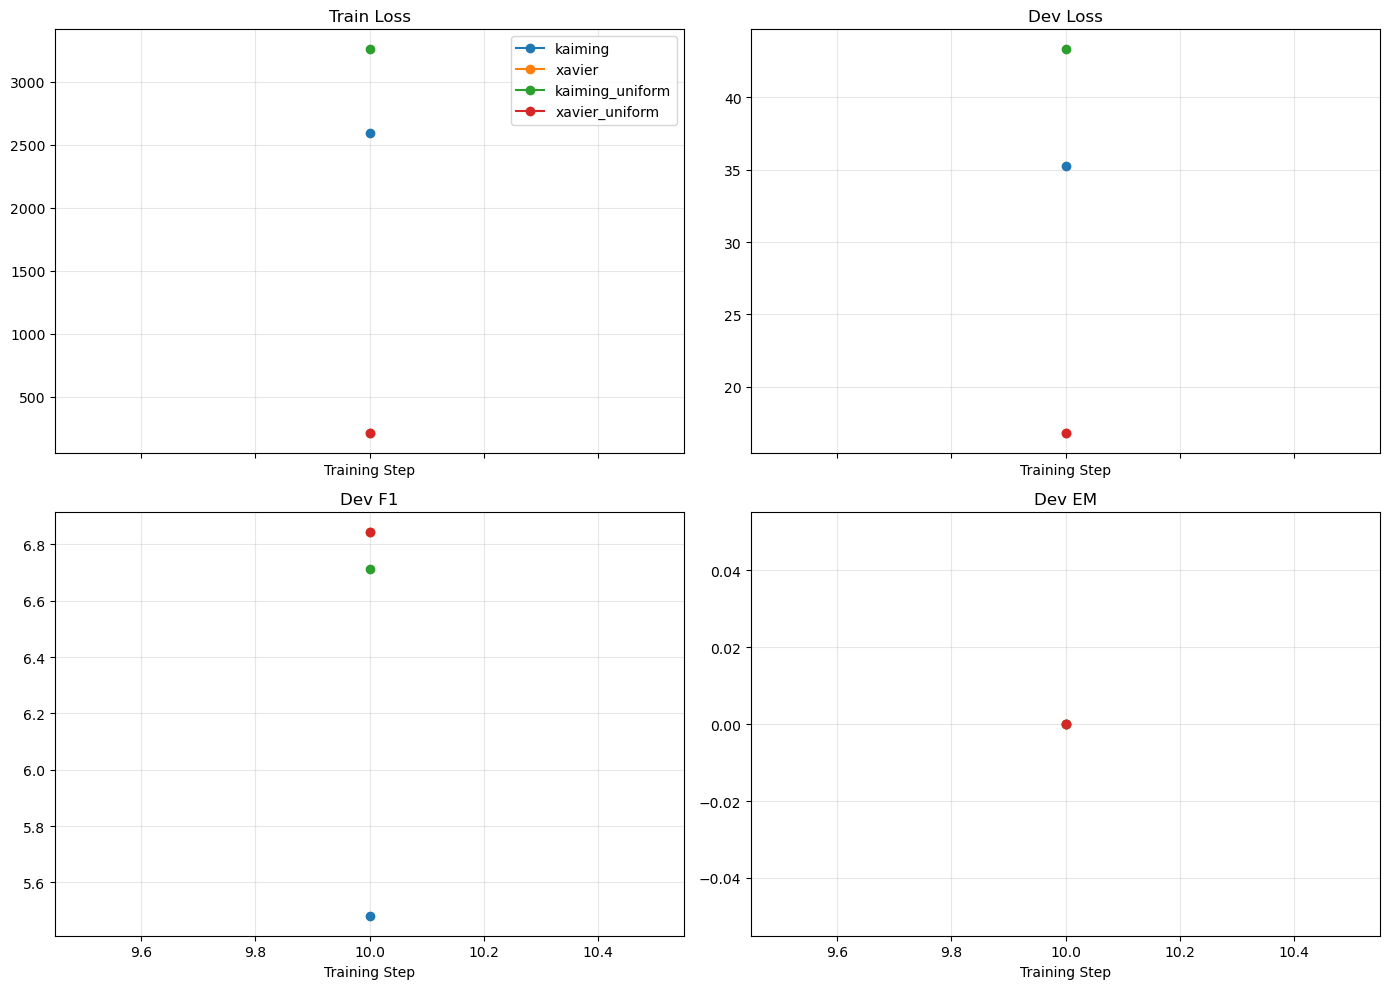

In [ ]:
train_results_disk = {}
available_settings_disk = []

for init_name in INIT_SETTINGS:
    train_path = RESULTS_DIR / f"train_{init_name}.json"
    if train_path.exists():
        with train_path.open("r", encoding="utf-8") as f:
            train_results_disk[init_name] = json.load(f)
        available_settings_disk.append(init_name)

if not available_settings_disk:
    raise ValueError("No saved training results available. Run training first.")

plt.close("all")
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

for init_name in available_settings_disk:
    history_df = pd.DataFrame(train_results_disk[init_name]["history"])
    axes[0, 0].plot(history_df["step"].tolist(), history_df["train_loss"].tolist(), marker="o", label=init_name)
    axes[0, 1].plot(history_df["step"].tolist(), history_df["dev_loss"].tolist(), marker="o", label=init_name)
    axes[1, 0].plot(history_df["step"].tolist(), history_df["dev_f1"].tolist(), marker="o", label=init_name)
    axes[1, 1].plot(history_df["step"].tolist(), history_df["dev_em"].tolist(), marker="o", label=init_name)

axes[0, 0].set_title("Train Loss")
axes[0, 1].set_title("Dev Loss")
axes[1, 0].set_title("Dev F1")
axes[1, 1].set_title("Dev EM")

for ax in axes.flat:
    ax.set_xlabel("Training Step")
    ax.grid(True, alpha=0.3)

axes[0, 0].legend()
plt.tight_layout()
plt.show()


---
## Final Metric Comparison

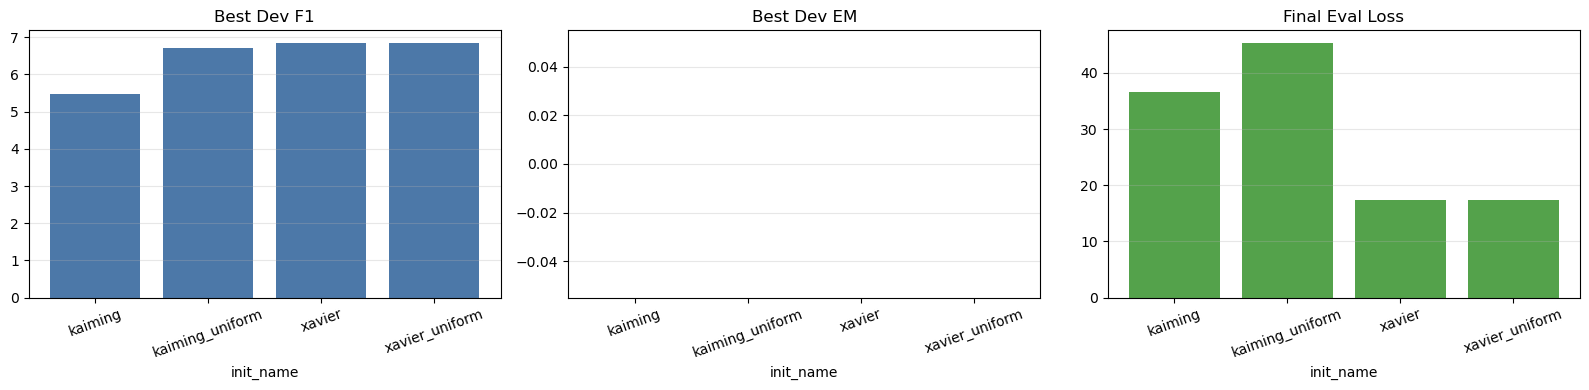

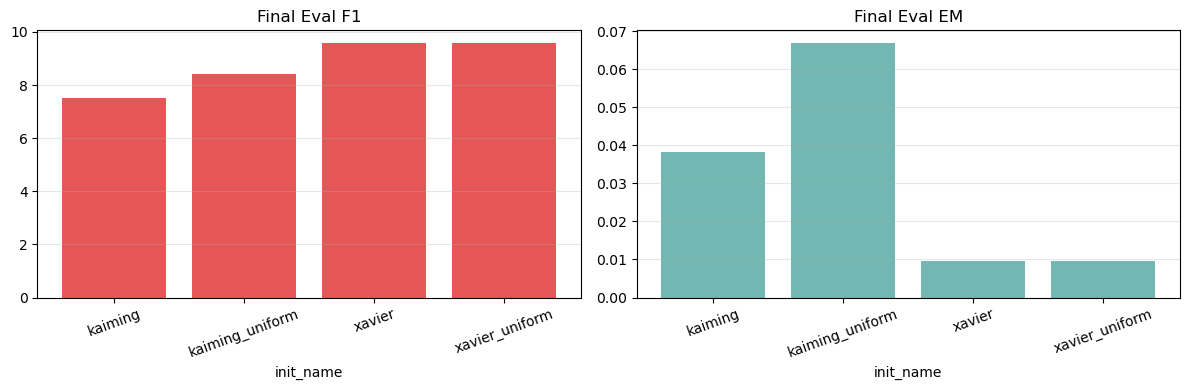

In [ ]:
train_results = {}
eval_results = {}
available_settings = []

for init_name in INIT_SETTINGS:
    train_path = RESULTS_DIR / f"train_{init_name}.json"
    eval_path = RESULTS_DIR / f"eval_{init_name}.json"
    if train_path.exists() and eval_path.exists():
        with train_path.open("r", encoding="utf-8") as f:
            train_results[init_name] = json.load(f)
        with eval_path.open("r", encoding="utf-8") as f:
            eval_results[init_name] = json.load(f)
        available_settings.append(init_name)

plot_rows = []
for init_name in available_settings:
    history = train_results[init_name]["history"]
    last_entry = history[-1]
    best_entry = max(history, key=lambda row: row["dev_f1"])
    plot_rows.append({
        "init_name": init_name,
        "best_dev_f1": train_results[init_name]["best_f1"],
        "best_dev_em": train_results[init_name]["best_em"],
        "best_dev_step": best_entry["step"],
        "eval_f1": eval_results[init_name]["f1"],
        "eval_em": eval_results[init_name]["exact_match"],
        "eval_loss": eval_results[init_name]["loss"],
    })

plot_df = pd.DataFrame(plot_rows)
if plot_df.empty:
    raise ValueError("No saved summary data is available. Run training/evaluation first.")

plot_df = plot_df.sort_values("init_name").reset_index(drop=True)
x_labels = plot_df["init_name"].tolist()

plt.close("all")
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(x_labels, plot_df["best_dev_f1"], color="#4C78A8")
axes[0].set_title("Best Dev F1")
axes[0].set_xlabel("init_name")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(x_labels, plot_df["best_dev_em"], color="#F58518")
axes[1].set_title("Best Dev EM")
axes[1].set_xlabel("init_name")
axes[1].tick_params(axis="x", rotation=20)

axes[2].bar(x_labels, plot_df["eval_loss"], color="#54A24B")
axes[2].set_title("Final Eval Loss")
axes[2].set_xlabel("init_name")
axes[2].tick_params(axis="x", rotation=20)

for ax in axes:
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(x_labels, plot_df["eval_f1"], color="#E45756")
axes[0].set_title("Final Eval F1")
axes[0].set_xlabel("init_name")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(x_labels, plot_df["eval_em"], color="#72B7B2")
axes[1].set_title("Final Eval EM")
axes[1].set_xlabel("init_name")
axes[1].tick_params(axis="x", rotation=20)

for ax in axes:
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


---
## Notes for Analysis

When writing the report, compare both the final metrics and the curve shapes:

- whether Kaiming converges faster than Xavier under ReLU activations
- whether normal and uniform variants differ mainly in early training stability
- whether lower loss also translates to better QA quality
- whether the strongest effect appears in early optimization or final evaluation

In [ ]:
train_results = {}
eval_results = {}
available_settings = []

for init_name in INIT_SETTINGS:
    train_path = RESULTS_DIR / f"train_{init_name}.json"
    eval_path = RESULTS_DIR / f"eval_{init_name}.json"
    if train_path.exists() and eval_path.exists():
        with train_path.open("r", encoding="utf-8") as f:
            train_results[init_name] = json.load(f)
        with eval_path.open("r", encoding="utf-8") as f:
            eval_results[init_name] = json.load(f)
        available_settings.append(init_name)

if not available_settings:
    print("No summary rows available.")
else:
    for init_name in available_settings:
        print(
            f"Init={init_name} | Best Dev F1={train_results[init_name]['best_f1']:.4f} | "
            f"Best Dev EM={train_results[init_name]['best_em']:.4f} | Eval F1={eval_results[init_name]['f1']:.4f} | "
            f"Eval EM={eval_results[init_name]['exact_match']:.4f} | Eval Loss={eval_results[init_name]['loss']:.6f}"
        )


Init=kaiming | Best Dev F1=5.4788 | Best Dev EM=0.0000 | Eval F1=7.5092 | Eval EM=0.0382 | Eval Loss=36.564910
Init=kaiming_uniform | Best Dev F1=6.7145 | Best Dev EM=0.0000 | Eval F1=8.4053 | Eval EM=0.0669 | Eval Loss=45.305082
Init=xavier | Best Dev F1=6.8455 | Best Dev EM=0.0000 | Eval F1=9.5799 | Eval EM=0.0096 | Eval Loss=17.309620
Init=xavier_uniform | Best Dev F1=6.8455 | Best Dev EM=0.0000 | Eval F1=9.5799 | Eval EM=0.0096 | Eval Loss=17.309620
